# Mutual Fund Performance Analytics

## Objective

This notebook evaluates the historical performance of mutual fund schemes using various financial performance metrics. The analysis includes daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Fund Scorecard, and Benchmark Comparison to assess the risk-adjusted performance of mutual funds.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

from scipy.stats import linregress

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

REPORTS = PROJECT_ROOT / "reports"

CHARTS = REPORTS / "charts"

fund_master = pd.read_csv(PROCESSED_DATA / "fund_master_cleaned.csv")

nav_history = pd.read_csv(
    PROCESSED_DATA / "nav_history_cleaned.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    PROCESSED_DATA / "scheme_performance_cleaned.csv"
)

benchmark = pd.read_csv(
    PROCESSED_DATA / "benchmark_indices_cleaned.csv",
    parse_dates=["date"]
)

In [3]:
print("Fund Master :", fund_master.shape)
print("NAV History :", nav_history.shape)
print("Performance :", performance.shape)
print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV History : (46000, 3)
Performance : (40, 19)
Benchmark : (8050, 3)


## 1. Daily Return Analysis

### Objective

Calculate daily returns for all mutual fund schemes using daily NAV values. Daily returns are the foundation for computing risk-adjusted performance metrics such as Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

In [4]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

In [5]:
nav_history["daily_return"] = (

    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()

)

In [6]:
nav_history.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [12]:
daily_returns = nav_history.dropna(
    subset=["daily_return"]
)

print(daily_returns.shape)

(45960, 4)


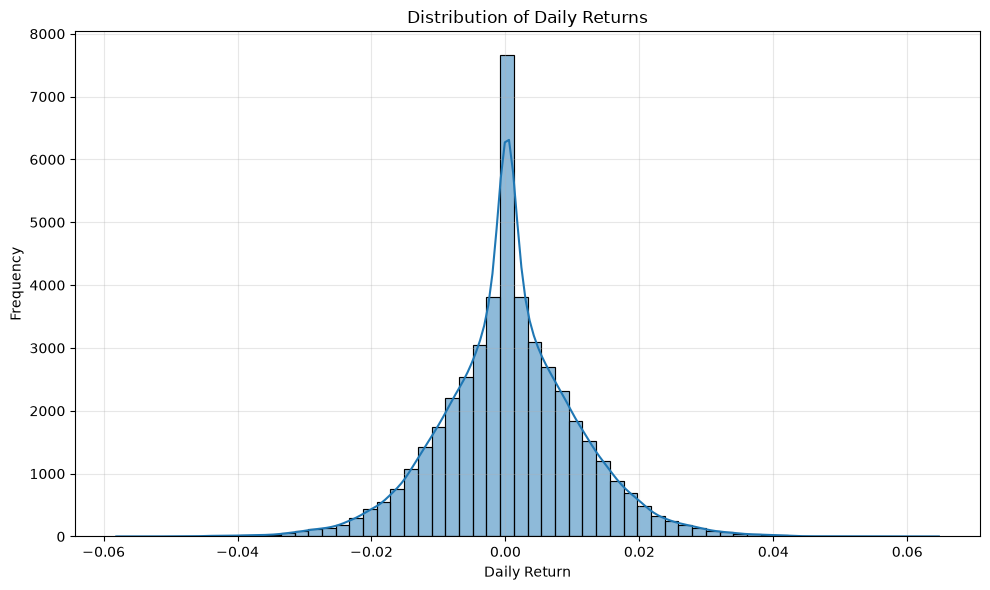

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(

    daily_returns["daily_return"],

    bins=60,

    kde=True

)

plt.title(
    "Distribution of Daily Returns"
)

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    CHARTS / "daily_return_distribution.png",
    dpi=300
)

plt.show()

### Observation

- Daily returns are concentrated around zero, indicating that large day-to-day price movements are relatively uncommon.
- The distribution shows both positive and negative returns, which is expected in financial time-series data.
- This distribution will be used for subsequent performance metrics such as Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

# 2. Compound Annual Growth Rate (CAGR)

## Objective

Calculate the Compound Annual Growth Rate (CAGR) for each mutual fund over 1-year, 3-year, and 5-year periods. CAGR measures the annualized growth rate of an investment, assuming profits are reinvested over the investment period.

In [14]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

In [15]:
def calculate_cagr(nav_data, years):

    results = []

    for fund in nav_data["amfi_code"].unique():

        df = nav_data[
            nav_data["amfi_code"] == fund
        ].sort_values("date")

        end_date = df["date"].max()
        start_date = end_date - pd.DateOffset(years=years)

        period = df[df["date"] >= start_date]

        if len(period) < 2:
            continue

        start_nav = period.iloc[0]["nav"]
        end_nav = period.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years)) - 1

        results.append(
            {
                "amfi_code": fund,
                f"cagr_{years}yr": cagr * 100
            }
        )

    return pd.DataFrame(results)

In [16]:
cagr_1 = calculate_cagr(nav_history, 1)

cagr_3 = calculate_cagr(nav_history, 3)

cagr_5 = calculate_cagr(nav_history, 5)

In [17]:
cagr_table = (
    cagr_1
    .merge(cagr_3, on="amfi_code")
    .merge(cagr_5, on="amfi_code")
    .merge(
        fund_master[
            ["amfi_code", "scheme_name"]
        ],
        on="amfi_code"
    )
)

In [18]:
cagr_table = cagr_table[
    [
        "amfi_code",
        "scheme_name",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
]

cagr_table.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [19]:
top_cagr = (
    cagr_table
    .sort_values(
        "cagr_5yr",
        ascending=False
    )
    .head(10)
)

top_cagr

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762
21,119598,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224
39,149324,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,27.917430
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277
30,120843,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
38,149323,DSP Midcap Fund - Regular - Growth,21.481222,26.869991,25.611807
16,119094,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.445309
19,119551,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873


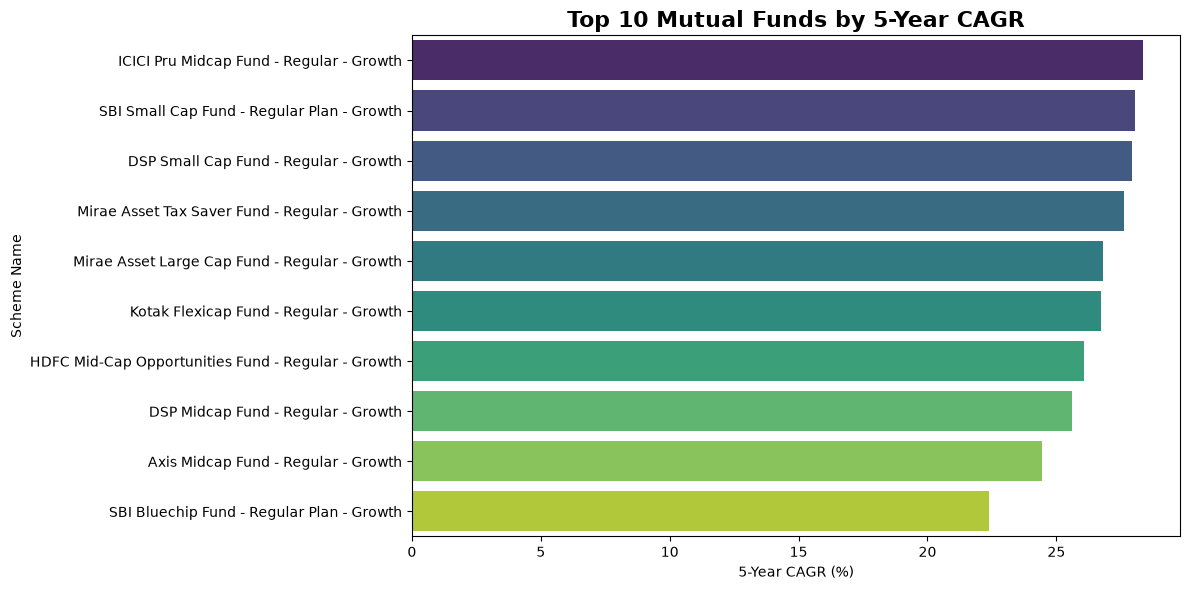

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cagr,
    x="cagr_5yr",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Mutual Funds by 5-Year CAGR",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("5-Year CAGR (%)")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(
    CHARTS / "top_10_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
cagr_table.to_csv(
    REPORTS / "cagr_comparison.csv",
    index=False
)

### Observation

- The CAGR analysis highlights the annualized growth achieved by each mutual fund over 1-year, 3-year, and 5-year periods.
- Funds with consistently higher 3-year and 5-year CAGR demonstrate stronger long-term performance.
- CAGR provides a standardized metric for comparing funds with different growth trajectories.

# 3. Sharpe Ratio Analysis

## Objective

Calculate the annualized Sharpe Ratio for each mutual fund scheme using daily returns. The Sharpe Ratio measures the return earned per unit of total risk and is widely used to compare risk-adjusted performance across investment funds.

In [22]:
RISK_FREE_RATE = 0.065

daily_rf = RISK_FREE_RATE / 252

daily_rf

0.00025793650793650796

In [23]:
sharpe = (

    daily_returns

    .groupby("amfi_code")["daily_return"]

    .agg(

        mean_return="mean",

        std_return="std"

    )

    .reset_index()

)

In [24]:
sharpe["sharpe_ratio"] = (

    (sharpe["mean_return"] - daily_rf)

    / sharpe["std_return"]

) * np.sqrt(252)

In [25]:
sharpe = sharpe.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code"

)

In [26]:
sharpe = sharpe.sort_values(

    "sharpe_ratio",

    ascending=False

)

sharpe.head(10)

,amfi_code,mean_return,std_return,sharpe_ratio,scheme_name
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


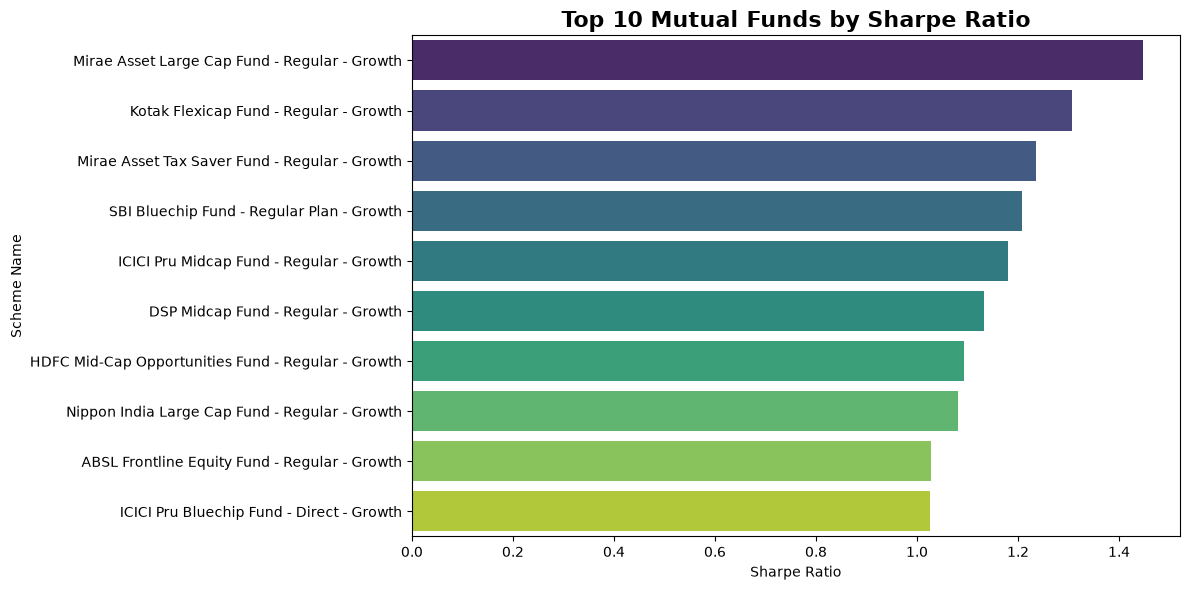

In [27]:
top_sharpe = sharpe.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=top_sharpe,

    x="sharpe_ratio",

    y="scheme_name",

    hue="scheme_name",

    palette="viridis",

    legend=False

)

plt.title(

    "Top 10 Mutual Funds by Sharpe Ratio",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    CHARTS / "sharpe_ratio.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [29]:
sharpe.to_csv(

    REPORTS / "sharpe_ratio.csv",

    index=False

)

### Observation

- Funds with higher Sharpe Ratios generated better risk-adjusted returns.
- A higher Sharpe Ratio indicates that a fund delivered more return for each unit of total risk.
- The ranking highlights the strongest performers after accounting for volatility rather than returns alone.

# 4. Sortino Ratio Analysis

## Objective

Calculate the annualized Sortino Ratio for each mutual fund scheme. The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility, making it particularly useful for measuring downside investment risk.

In [30]:
def calculate_sortino(group):

    mean_return = group["daily_return"].mean()

    downside_returns = group.loc[
        group["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        return np.nan

    return (
        (mean_return - daily_rf)
        / downside_std
    ) * np.sqrt(252)

In [31]:
sortino = (

    daily_returns

    .groupby("amfi_code")

    .apply(calculate_sortino)

    .reset_index(name="sortino_ratio")

)

In [32]:
sortino = sortino.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code"

)

In [33]:
sortino = sortino.sort_values(

    "sortino_ratio",

    ascending=False

)

sortino.head(10)

,amfi_code,sortino_ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


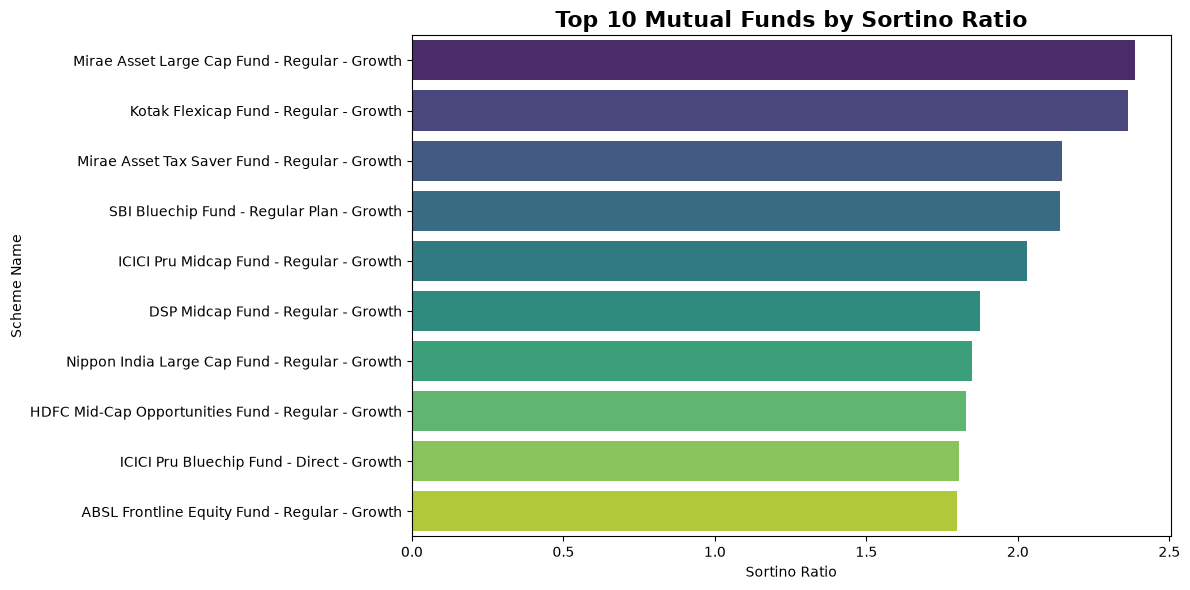

In [34]:
top_sortino = sortino.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=top_sortino,

    x="sortino_ratio",

    y="scheme_name",

    hue="scheme_name",

    palette="viridis",

    legend=False

)

plt.title(

    "Top 10 Mutual Funds by Sortino Ratio",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    CHARTS / "sortino_ratio.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [35]:
sortino.to_csv(

    REPORTS / "sortino_ratio.csv",

    index=False

)

### Observation

- The Sortino Ratio focuses only on downside risk, ignoring positive volatility.
- Funds with higher Sortino Ratios achieved stronger returns while experiencing relatively lower downside fluctuations.
- Compared to the Sharpe Ratio, the Sortino Ratio provides a more targeted assessment of downside risk-adjusted performance.

# 5. Alpha & Beta Analysis

## Objective

Estimate Alpha and Beta for each mutual fund by regressing daily fund returns against Nifty 100 daily returns using Ordinary Least Squares (OLS). Beta measures market sensitivity, while Alpha measures excess return after adjusting for market risk.

In [36]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [41]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [43]:
nifty100 = nifty100.sort_values("date")

nifty100["market_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,market_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [44]:
alpha_beta = []

for fund in daily_returns["amfi_code"].unique():

    fund_df = daily_returns[
        daily_returns["amfi_code"] == fund
    ]

    merged = fund_df.merge(

        nifty100[
            ["date", "market_return"]
        ],

        on="date",

        how="inner"

    )

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(

        merged["market_return"],

        merged["daily_return"]

    )

    alpha_beta.append({

        "amfi_code": fund,

        "alpha": intercept * 252,

        "beta": slope,

        "r_squared": r_value ** 2

    })

alpha_beta = pd.DataFrame(alpha_beta)

In [45]:
alpha_beta = alpha_beta.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code"

)

alpha_beta.head()

,amfi_code,alpha,beta,r_squared,scheme_name
0,100016,0.037476,-0.058268,0.002665,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,0.000015,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,0.000012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,0.000348,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,0.001064,ABSL Small Cap Fund - Regular - Growth


In [46]:
alpha_beta = alpha_beta.sort_values(

    "alpha",

    ascending=False

)

alpha_beta.head(10)

,amfi_code,alpha,beta,r_squared,scheme_name
21,119598,0.303370,-0.023196,1.414258e-04,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,3.532991e-05,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,1.345534e-07,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,1.748889e-04,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,3.430543e-04,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,1.206652e-05,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,4.625437e-04,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,3.357978e-06,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,1.936879e-03,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,8.869789e-04,SBI Bluechip Fund - Regular Plan - Growth


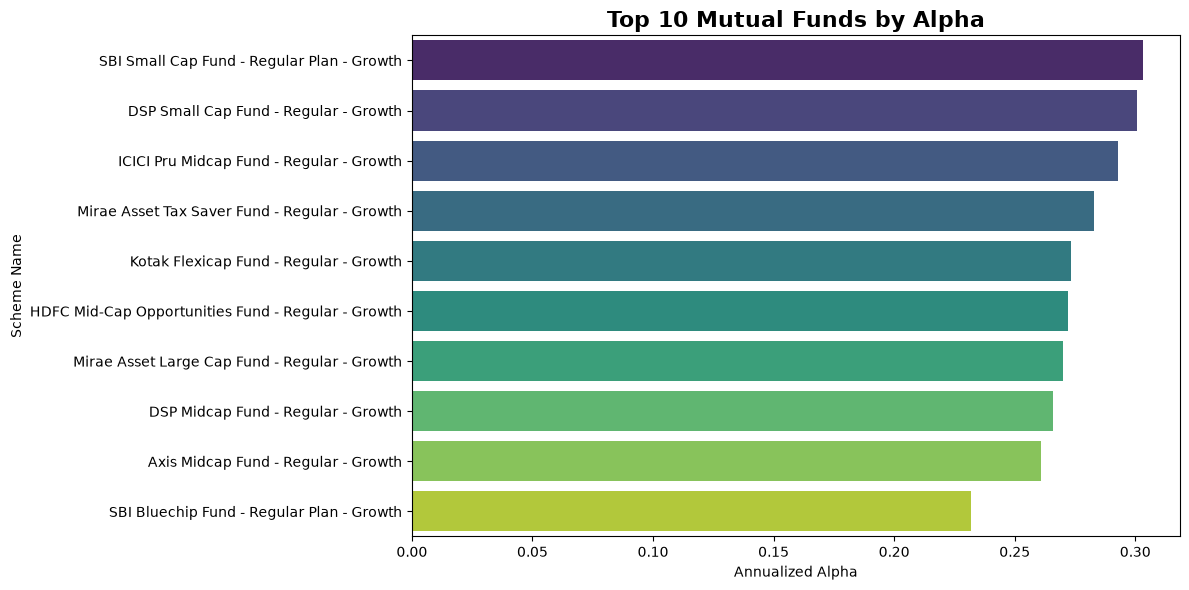

In [47]:
top_alpha = alpha_beta.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=top_alpha,

    x="alpha",

    y="scheme_name",

    hue="scheme_name",

    palette="viridis",

    legend=False

)

plt.title(

    "Top 10 Mutual Funds by Alpha",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Annualized Alpha")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    CHARTS / "alpha_ranking.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [48]:
alpha_beta.to_csv(

    REPORTS / "alpha_beta.csv",

    index=False

)

### Observation

- Funds with positive Alpha outperformed the benchmark after accounting for market risk.
- Beta values greater than 1 indicate higher sensitivity to market movements, while values below 1 suggest lower market volatility.
- Alpha and Beta together provide valuable insight into fund manager performance and market exposure.

# 6. Maximum Drawdown Analysis

## Objective

Calculate the Maximum Drawdown (MDD) for each mutual fund scheme. Maximum Drawdown represents the largest percentage decline from a historical peak and is widely used to evaluate downside investment risk.

In [49]:
drawdown_df = nav_history.copy()

drawdown_df["running_max"] = (

    drawdown_df

    .groupby("amfi_code")["nav"]

    .cummax()

)

drawdown_df.head()

,amfi_code,date,nav,daily_return,running_max
0,100016,2022-01-03,520.4608,NaN,520.4608
1,100016,2022-01-04,515.0971,-0.010306,520.4608
2,100016,2022-01-05,521.7239,0.012865,521.7239
3,100016,2022-01-06,515.7880,-0.011377,521.7239
4,100016,2022-01-07,515.1639,-0.001210,521.7239


In [50]:
drawdown_df["drawdown"] = (

    drawdown_df["nav"]

    / drawdown_df["running_max"]

) - 1

drawdown_df.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [51]:
max_drawdown = (

    drawdown_df

    .groupby("amfi_code")

    .agg(

        max_drawdown=("drawdown", "min")

    )

    .reset_index()

)

max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [52]:
worst_dates = (

    drawdown_df

    .loc[

        drawdown_df.groupby("amfi_code")["drawdown"].idxmin(),

        ["amfi_code", "date"]

    ]

    .rename(columns={"date": "worst_drawdown_date"})

)

worst_dates.head()

,amfi_code,worst_drawdown_date
183,100016,2022-09-15
1559,100025,2023-07-28
2393,100033,2022-05-12
3842,101206,2023-07-05
5735,101207,2026-05-11


In [53]:
max_drawdown = (

    max_drawdown

    .merge(worst_dates, on="amfi_code")

    .merge(

        fund_master[

            ["amfi_code", "scheme_name"]

        ],

        on="amfi_code"

    )

)

max_drawdown.head()

,amfi_code,max_drawdown,worst_drawdown_date,scheme_name
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [54]:
max_drawdown = max_drawdown.sort_values(

    "max_drawdown"

)

max_drawdown.head(10)

,amfi_code,max_drawdown,worst_drawdown_date,scheme_name
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth


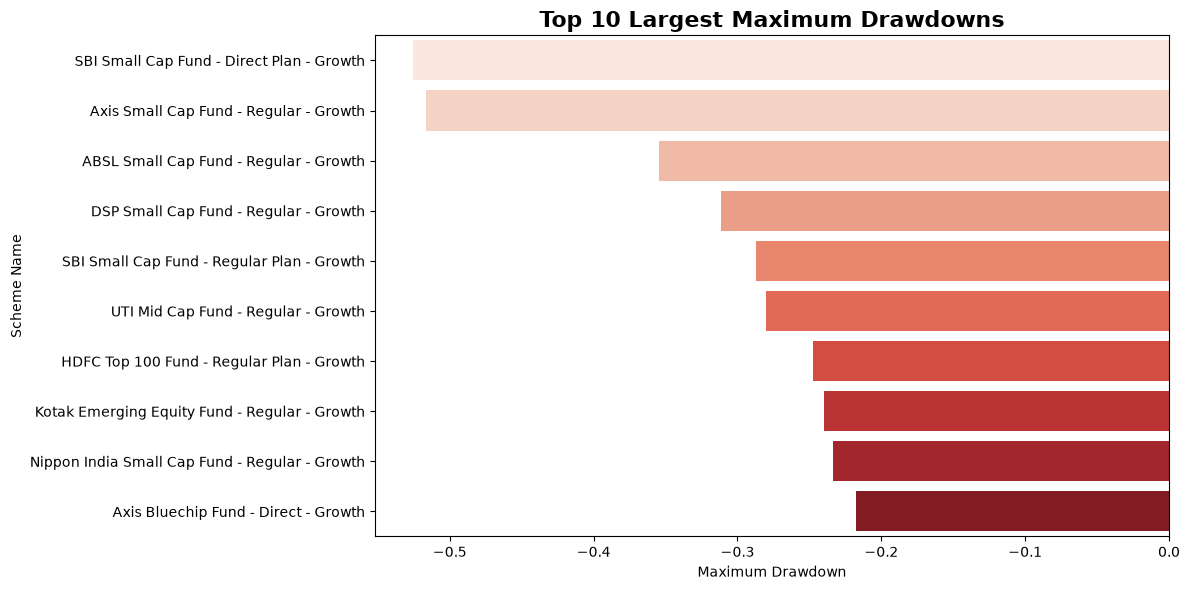

In [55]:
worst_drawdowns = max_drawdown.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=worst_drawdowns,

    x="max_drawdown",

    y="scheme_name",

    hue="scheme_name",

    palette="Reds",

    legend=False

)

plt.title(

    "Top 10 Largest Maximum Drawdowns",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Maximum Drawdown")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    CHARTS / "maximum_drawdown.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [56]:
max_drawdown.to_csv(

    REPORTS / "maximum_drawdown.csv",

    index=False

)

### Observation

- Maximum Drawdown quantifies the largest decline from a historical NAV peak.
- Funds with smaller drawdowns demonstrated better downside protection during market declines.
- This metric complements the Sharpe and Sortino Ratios by specifically focusing on capital preservation.

# 7. Fund Scorecard

## Objective

Develop a composite performance score (0–100) by combining return, risk-adjusted performance, alpha generation, expense ratio, and downside risk. The score helps rank mutual funds using multiple evaluation criteria instead of relying on a single metric.

In [57]:
scorecard = performance[
    [
        "amfi_code",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard.head()

,amfi_code,return_3yr_pct,expense_ratio_pct
0,119551,12.36,1.54
1,119552,11.30,0.66
2,119598,23.39,1.43
3,119599,23.14,0.72
4,119120,6.07,0.77


In [58]:
scorecard = (
    scorecard
    .merge(
        sharpe[
            ["amfi_code", "sharpe_ratio"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta[
            ["amfi_code", "alpha"]
        ],
        on="amfi_code"
    )
    .merge(
        max_drawdown[
            ["amfi_code", "max_drawdown"]
        ],
        on="amfi_code"
    )
)

In [59]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

In [60]:
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

In [61]:
rank_cols = [
    "return_rank",
    "sharpe_rank",
    "alpha_rank",
    "expense_rank",
    "drawdown_rank"
]

for col in rank_cols:

    scorecard[col] = (
        (
            scorecard[col].max()
            - scorecard[col]
        )
        /
        (
            scorecard[col].max()
            - scorecard[col].min()
        )
    ) * 100

In [62]:
scorecard["fund_score"] = (

      scorecard["return_rank"] * 0.30

    + scorecard["sharpe_rank"] * 0.25

    + scorecard["alpha_rank"] * 0.20

    + scorecard["expense_rank"] * 0.15

    + scorecard["drawdown_rank"] * 0.10

)

In [63]:
scorecard = scorecard.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code"

)

scorecard = scorecard.sort_values(

    "fund_score",

    ascending=False

)

scorecard.head(10)

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,scheme_name
12,120505,18.08,1.36,1.180101,0.292636,-0.181885,82.051282,89.743590,94.871795,63.636364,38.461538,79.417249,ICICI Pru Midcap Fund - Regular - Growth
22,120843,15.65,1.45,1.306744,0.273305,-0.129740,74.358974,97.435897,89.743590,45.454545,69.230769,78.356643,Kotak Flexicap Fund - Regular - Growth
7,100033,16.58,1.38,1.093699,0.271954,-0.162172,76.923077,84.615385,87.179487,58.441558,51.282051,75.561106,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,119598,23.39,1.43,0.945308,0.303370,-0.287060,100.000000,66.666667,100.000000,48.051948,10.256410,74.900100,SBI Small Cap Fund - Regular Plan - Growth
34,148567,14.81,1.46,1.448291,0.269838,-0.112657,58.974359,100.000000,84.615385,42.857143,82.051282,74.249084,Mirae Asset Large Cap Fund - Regular - Growth
39,149324,20.08,1.52,0.949796,0.300579,-0.311719,87.179487,69.230769,97.435897,33.766234,7.692308,68.782884,DSP Small Cap Fund - Regular - Growth
38,149323,17.16,1.61,1.132122,0.265986,-0.172481,79.487179,87.179487,82.051282,3.896104,46.153846,67.251082,DSP Midcap Fund - Regular - Growth
11,120504,14.41,0.80,1.026524,0.211948,-0.125883,51.282051,76.923077,69.230769,71.428571,71.794872,66.355311,ICICI Pru Bluechip Fund - Direct - Growth
26,119094,15.18,1.38,0.998231,0.260767,-0.209609,64.102564,74.358974,79.487179,58.441558,30.769231,65.561106,Axis Midcap Fund - Regular - Growth
36,148569,13.58,1.60,1.234930,0.282704,-0.163967,43.589744,94.871795,92.307692,7.792208,48.717949,61.297036,Mirae Asset Tax Saver Fund - Regular - Growth


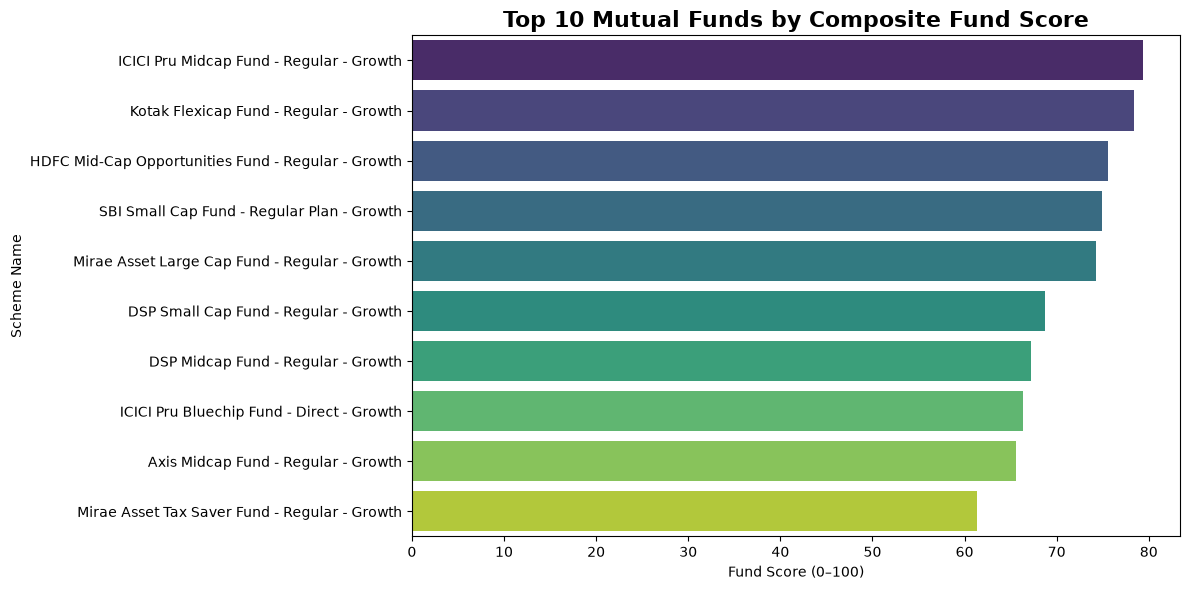

In [64]:
top_score = scorecard.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=top_score,

    x="fund_score",

    y="scheme_name",

    hue="scheme_name",

    palette="viridis",

    legend=False

)

plt.title(
    "Top 10 Mutual Funds by Composite Fund Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(
    CHARTS / "fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
scorecard.to_csv(
    REPORTS / "fund_scorecard.csv",
    index=False
)

### Observation

- The composite fund score integrates multiple performance and risk metrics into a single ranking.
- Funds with high returns, strong risk-adjusted performance, lower expense ratios, and smaller drawdowns achieved the highest overall scores.
- The scorecard provides a balanced framework for comparing mutual funds across multiple dimensions.

# 8. Benchmark Comparison & Tracking Error

## Objective

Compare the performance of the top five mutual funds with the NIFTY50 and NIFTY100 benchmark indices over the last three years. Additionally, calculate the Tracking Error to evaluate how closely each fund follows the benchmark.

In [66]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[120505, 120843, 100033, 119598, 148567]

In [67]:
latest_date = nav_history["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

top5_nav = nav_history[
    (nav_history["amfi_code"].isin(top5)) &
    (nav_history["date"] >= start_date)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2665,100033,2023-05-29,147.2155,0.004216
2666,100033,2023-05-30,147.2007,-0.000101
2667,100033,2023-05-31,147.4640,0.001789
2668,100033,2023-06-01,146.5954,-0.005890
2669,100033,2023-06-02,145.8015,-0.005416


In [68]:
top5_nav = top5_nav.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100033,2023-05-29,147.2155,0.004216,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,100033,2023-05-30,147.2007,-0.000101,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,100033,2023-05-31,147.4640,0.001789,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,100033,2023-06-01,146.5954,-0.005890,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,100033,2023-06-02,145.8015,-0.005416,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [69]:
benchmark_plot = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

benchmark_plot = benchmark_plot[
    benchmark_plot["date"] >= start_date
]

In [70]:
top5_nav["normalized_nav"] = (

    top5_nav

    .groupby("scheme_name")["nav"]

    .transform(lambda x: x / x.iloc[0] * 100)

)

benchmark_plot["normalized_close"] = (

    benchmark_plot

    .groupby("index_name")["close_value"]

    .transform(lambda x: x / x.iloc[0] * 100)

)

In [71]:
fig = px.line(

    top5_nav,

    x="date",

    y="normalized_nav",

    color="scheme_name",

    title="Top 5 Mutual Funds vs Benchmarks (3-Year Performance)",

    labels={
        "normalized_nav": "Normalized Value (Base = 100)",
        "date": "Date"
    }

)

In [72]:
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_plot[
        benchmark_plot["index_name"] == index
    ]

    fig.add_scatter(

        x=temp["date"],

        y=temp["normalized_close"],

        mode="lines",

        name=index,

        line=dict(width=4)

    )

In [73]:
fig.update_layout(

    width=1200,

    height=700,

    template="plotly_white",

    legend_title="Fund / Benchmark"

)

fig.write_image(

    CHARTS / "benchmark_comparison.png",

    width=1400,

    height=900,

    scale=2

)

fig.show()

In [74]:
benchmark_returns = benchmark_plot[
    benchmark_plot["index_name"] == "NIFTY100"
][
    ["date", "close_value"]
].copy()

benchmark_returns["benchmark_return"] = (
    benchmark_returns["close_value"]
    .pct_change()
)

benchmark_returns = benchmark_returns.dropna()

In [75]:
tracking_error = []

for fund in top5:

    fund_df = daily_returns[
        daily_returns["amfi_code"] == fund
    ]

    merged = fund_df.merge(

        benchmark_returns[
            ["date", "benchmark_return"]
        ],

        on="date",

        how="inner"

    )

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error.append({

        "amfi_code": fund,

        "tracking_error": te

    })

tracking_error = pd.DataFrame(tracking_error)

In [76]:
tracking_error = tracking_error.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code"

)

tracking_error

,amfi_code,tracking_error,scheme_name
0,120505,0.232661,ICICI Pru Midcap Fund - Regular - Growth
1,120843,0.206540,Kotak Flexicap Fund - Regular - Growth
2,100033,0.224976,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,119598,0.286689,SBI Small Cap Fund - Regular Plan - Growth
4,148567,0.187974,Mirae Asset Large Cap Fund - Regular - Growth


In [77]:
tracking_error.to_csv(

    REPORTS / "tracking_error.csv",

    index=False

)

### Observation

- The benchmark comparison chart illustrates the relative performance of the top five mutual funds against the NIFTY50 and NIFTY100 indices over the past three years.
- Funds that consistently outperform the benchmark demonstrate stronger long-term performance.
- Lower Tracking Error indicates that a fund closely follows the benchmark, whereas higher Tracking Error reflects greater deviation from benchmark returns.